In [1]:
!pip install pyfaidx tqdm pandas

In [2]:
!wget https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz

--2026-06-12 15:53:07--  https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.11, 130.14.250.12, 2607:f220:41e:250::31, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.11|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 439336125 (419M) [application/x-gzip]
Saving to: ‘variant_summary.txt.gz’

variant_summary.txt 100%[===================>] 418.98M  66.0MB/s    in 7.1s    

2026-06-12 15:53:14 (59.3 MB/s) - ‘variant_summary.txt.gz’ saved [439336125/439336125]



In [3]:
import pandas as pd

df = pd.read_csv(
    "variant_summary.txt.gz",
    sep="\t",
    usecols=[
        "Type",
        "Assembly",
        "ClinicalSignificance",
        "Chromosome",
        "Start",
        "ReferenceAlleleVCF",
        "AlternateAlleleVCF"
    ],
    dtype={
        "Type": "string",
        "Assembly": "string",
        "ClinicalSignificance": "string",
        "Chromosome": "string",
        "ReferenceAlleleVCF": "string",
        "AlternateAlleleVCF": "string"
    }
)

df = df[
    (df["Type"] == "single nucleotide variant") &
    (df["Assembly"] == "GRCh38") &
    (df["ClinicalSignificance"].isin([
        "Pathogenic",
        "Benign"
    ]))
].copy()

df = df[[
    "Chromosome",
    "Start",
    "ReferenceAlleleVCF",
    "AlternateAlleleVCF",
    "ClinicalSignificance"
]]

df.columns = [
    "chromosome",
    "position",
    "ref",
    "alt",
    "clinical_significance"
]

valid_bases = ["A", "C", "G", "T"]

df = df[
    df["ref"].isin(valid_bases) &
    df["alt"].isin(valid_bases) &
    (df["ref"] != df["alt"])
]

df.to_csv("variants.csv", index=False)

print(df.head())
print("\nRows:", len(df))
print("\nLabel Distribution:")
print(df["clinical_significance"].value_counts())

   chromosome   position ref alt clinical_significance
7          11  126275389   C   T            Pathogenic
23          6   26093008   G   A                Benign
31          6   26093215   G   T            Pathogenic
35          2   19989284   T   C            Pathogenic
37          2   19945787   T   C            Pathogenic

Rows: 264526

Label Distribution:
clinical_significance
Benign        179914
Pathogenic     84612
Name: count, dtype: Int64


In [4]:
print(df["chromosome"].value_counts().head(20))

chromosome
1     22088
2     21274
17    16785
X     16671
11    14647
3     13908
12    13402
7     13133
5     12882
16    12406
19    12110
6     11983
9     11578
15     9790
10     9770
8      8912
4      8756
14     7393
22     5927
13     5877
Name: count, dtype: Int64


In [5]:
import pandas as pd

# Load main variants file
df = pd.read_csv("variants.csv")

print("Original rows:", len(df))

# Keep only needed labels
valid = [
    "Benign",
    "Pathogenic"
]

df = df[df["clinical_significance"].isin(valid)].copy()

# Keep required columns
df = df[[
    "chromosome",
    "position",
    "ref",
    "alt",
    "clinical_significance"
]]

# Save filtered full dataset
df.to_csv("variants_filtered.csv", index=False)

print("Saved variants_filtered.csv")
print("Rows:", len(df))

print("\nLabel Distribution:")
print(df["clinical_significance"].value_counts())

print(df.head())

Original rows: 264526
Saved variants_filtered.csv
Rows: 264526

Label Distribution:
clinical_significance
Benign        179914
Pathogenic     84612
Name: count, dtype: int64
  chromosome   position ref alt clinical_significance
0         11  126275389   C   T            Pathogenic
1          6   26093008   G   A                Benign
2          6   26093215   G   T            Pathogenic
3          2   19989284   T   C            Pathogenic
4          2   19945787   T   C            Pathogenic


In [6]:
import pandas as pd

# -----------------------------------
# LOAD FILTERED MASTER DATASET
# -----------------------------------
df = pd.read_csv("variants_filtered.csv")

df["chromosome"] = df["chromosome"].astype(str).str.upper()

# Standard chromosomes only
# Chromosomes used by GeneScope

VALID_CHROMS = [
    "1","2","3","5","7",
    "11","16","17","19","X"
]

df = df[
    df["chromosome"].isin(VALID_CHROMS)
]

# -----------------------------------
# SPLIT LABELS
# -----------------------------------
benign_terms = ["Benign"]
path_terms   = ["Pathogenic"]

benign_df = df[df["clinical_significance"].isin(benign_terms)]
path_df   = df[df["clinical_significance"].isin(path_terms)]

print("Benign rows:", len(benign_df))
print("Pathogenic rows:", len(path_df))

# -----------------------------------
# SAMPLE 20000 + 20000
# -----------------------------------
N = min(len(benign_df), len(path_df), 20000)

benign_sample = benign_df.sample(N, random_state=42)
path_sample   = path_df.sample(N, random_state=42)

# combine + shuffle
final_df = pd.concat([benign_sample, path_sample])
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

# save
final_df.to_csv("variants_multichrom_40k.csv", index=False)

print("\nSaved: variants_multichrom_40k.csv")
print("Rows:", len(final_df))

print("\nClass counts:")
print(final_df["clinical_significance"].value_counts())

print("\nChromosome counts:")
print(final_df["chromosome"].value_counts().sort_index())

Benign rows: 102595
Pathogenic rows: 53309

Saved: variants_multichrom_40k.csv
Rows: 40000

Class counts:
clinical_significance
Pathogenic    20000
Benign        20000
Name: count, dtype: int64

Chromosome counts:
chromosome
1     5483
11    3815
16    3251
17    4375
19    2908
2     5408
3     3562
5     3253
7     3299
X     4646
Name: count, dtype: int64


In [7]:
import pandas as pd

df = pd.read_csv("variants_multichrom_40k.csv")
print(df["chromosome"].value_counts())

chromosome
1     5483
2     5408
X     4646
17    4375
11    3815
3     3562
7     3299
5     3253
16    3251
19    2908
Name: count, dtype: int64


In [8]:
df = pd.read_csv("variants_multichrom_40k.csv")

print(df["clinical_significance"].value_counts())

print(df.groupby("chromosome")["clinical_significance"].value_counts())

clinical_significance
Pathogenic    20000
Benign        20000
Name: count, dtype: int64
chromosome  clinical_significance
1           Benign                   3030
            Pathogenic               2453
11          Benign                   1976
            Pathogenic               1839
16          Pathogenic               1644
            Benign                   1607
17          Pathogenic               2419
            Benign                   1956
19          Benign                   1790
            Pathogenic               1118
2           Pathogenic               2788
            Benign                   2620
3           Benign                   1860
            Pathogenic               1702
5           Benign                   1797
            Pathogenic               1456
7           Benign                   1782
            Pathogenic               1517
X           Pathogenic               3064
            Benign                   1582
Name: count, dtype: int64


In [9]:
!wget -c https://ftp.ensembl.org/pub/release-110/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.1.fa.gz
!wget -c https://ftp.ensembl.org/pub/release-110/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.2.fa.gz
!wget -c https://ftp.ensembl.org/pub/release-110/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.3.fa.gz
!wget -c https://ftp.ensembl.org/pub/release-110/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.5.fa.gz
!wget -c https://ftp.ensembl.org/pub/release-110/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.7.fa.gz
!wget -c https://ftp.ensembl.org/pub/release-110/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.11.fa.gz
!wget -c https://ftp.ensembl.org/pub/release-110/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.16.fa.gz
!wget -c https://ftp.ensembl.org/pub/release-110/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.17.fa.gz
!wget -c https://ftp.ensembl.org/pub/release-110/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.19.fa.gz
!wget -c https://ftp.ensembl.org/pub/release-110/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.X.fa.gz

--2026-06-12 15:54:46--  https://ftp.ensembl.org/pub/release-110/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.1.fa.gz
Resolving ftp.ensembl.org (ftp.ensembl.org)... 193.62.193.169
Connecting to ftp.ensembl.org (ftp.ensembl.org)|193.62.193.169|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 69273468 (66M) [application/x-gzip]
Saving to: ‘Homo_sapiens.GRCh38.dna.chromosome.1.fa.gz’

Homo_sapiens.GRCh38 100%[===================>]  66.06M  14.7MB/s    in 5.2s    

2026-06-12 15:54:52 (12.7 MB/s) - ‘Homo_sapiens.GRCh38.dna.chromosome.1.fa.gz’ saved [69273468/69273468]

--2026-06-12 15:54:52--  https://ftp.ensembl.org/pub/release-110/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.2.fa.gz
Resolving ftp.ensembl.org (ftp.ensembl.org)... 193.62.193.169
Connecting to ftp.ensembl.org (ftp.ensembl.org)|193.62.193.169|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72794281 (69M) [application/x-gzip]
Saving to: ‘Homo_sapiens

In [10]:
import os
files = [f for f in os.listdir() if f.endswith(".fa.gz")]
print(files)

['Homo_sapiens.GRCh38.dna.chromosome.7.fa.gz', 'Homo_sapiens.GRCh38.dna.chromosome.2.fa.gz', 'Homo_sapiens.GRCh38.dna.chromosome.17.fa.gz', 'Homo_sapiens.GRCh38.dna.chromosome.19.fa.gz', 'Homo_sapiens.GRCh38.dna.chromosome.11.fa.gz', 'Homo_sapiens.GRCh38.dna.chromosome.X.fa.gz', 'Homo_sapiens.GRCh38.dna.chromosome.16.fa.gz', 'Homo_sapiens.GRCh38.dna.chromosome.1.fa.gz', 'Homo_sapiens.GRCh38.dna.chromosome.5.fa.gz', 'Homo_sapiens.GRCh38.dna.chromosome.3.fa.gz']


In [11]:
# ==========================================================
# GENESCOPE AI — PHASE 1 (STRICT DATASET VERSION)
# ==========================================================

import pandas as pd
import gzip
import os
from tqdm import tqdm

# ==========================================================
# CONFIG
# ==========================================================

INPUT_FILE = "variants_multichrom_40k.csv"

REFERENCE_FILES = {
    "1": "Homo_sapiens.GRCh38.dna.chromosome.1.fa.gz",
    "2": "Homo_sapiens.GRCh38.dna.chromosome.2.fa.gz",
    "3": "Homo_sapiens.GRCh38.dna.chromosome.3.fa.gz",
    "5": "Homo_sapiens.GRCh38.dna.chromosome.5.fa.gz",
    "7": "Homo_sapiens.GRCh38.dna.chromosome.7.fa.gz",
    "11": "Homo_sapiens.GRCh38.dna.chromosome.11.fa.gz",
    "16": "Homo_sapiens.GRCh38.dna.chromosome.16.fa.gz",
    "17": "Homo_sapiens.GRCh38.dna.chromosome.17.fa.gz",
    "19": "Homo_sapiens.GRCh38.dna.chromosome.19.fa.gz",
    "X": "Homo_sapiens.GRCh38.dna.chromosome.X.fa.gz"
}

WINDOW = 101
HALF = WINDOW // 2

OUTPUT_DIR = "output"

FINAL_FILE = f"{OUTPUT_DIR}/final_dataset.csv"

SKIPPED_FILE = f"{OUTPUT_DIR}/skipped_rows.csv"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================================
# FASTA LOADER
# ==========================================================

def load_fasta(filename):

    seq = []

    with gzip.open(filename, "rt") as f:

        for line in f:

            if line.startswith(">"):
                continue

            seq.append(line.strip().upper())

    return "".join(seq)

# ==========================================================
# LOAD CHROMOSOMES
# ==========================================================

reference = {}

print("Loading chromosome references...")

for chrom, file in REFERENCE_FILES.items():

    if os.path.exists(file):

        print("Loading chr", chrom)

        reference[chrom] = load_fasta(file)

    else:

        print("Missing:", file)

print("\nLoaded chromosomes:", list(reference.keys()))

# ==========================================================
# LABEL FUNCTION
# ==========================================================

def make_label(x):

    x = str(x).strip().lower()

    if x == "pathogenic":
        return 1

    elif x == "benign":
        return 0

    return None

# ==========================================================
# LOAD DATA
# ==========================================================

df = pd.read_csv(INPUT_FILE)

df["chromosome"] = (
    df["chromosome"]
    .astype(str)
    .str.upper()
)

# ==========================================================
# REMOVE DUPLICATES
# ==========================================================

df = df.drop_duplicates(
    subset=[
        "chromosome",
        "position",
        "ref",
        "alt"
    ]
)

print("\nRows after deduplication:", len(df))

# ==========================================================
# MAIN
# ==========================================================

good_rows = []

bad_rows = []

stats = {

    "total_rows": len(df),

    "kept_rows": 0,

    "missing_chr": 0,

    "invalid_base": 0,

    "out_of_bounds": 0,

    "contains_N": 0,

    "ref_mismatch": 0,

    "invalid_label": 0
}

print("\nGenerating sequences...")

for _, row in tqdm(df.iterrows(), total=len(df)):

    chrom = row["chromosome"]

    pos = int(row["position"])

    ref = str(row["ref"]).upper()

    alt = str(row["alt"]).upper()

    # ------------------------------------------------------
    # chromosome exists
    # ------------------------------------------------------

    if chrom not in reference:

        stats["missing_chr"] += 1

        bad_rows.append(row)

        continue

    # ------------------------------------------------------
    # valid SNP only
    # ------------------------------------------------------

    if ref not in "ACGT" or alt not in "ACGT":

        stats["invalid_base"] += 1

        bad_rows.append(row)

        continue

    # ------------------------------------------------------
    # remove self mutations
    # ------------------------------------------------------

    if ref == alt:

        stats["invalid_base"] += 1

        bad_rows.append(row)

        continue

    seq = reference[chrom]

    start = pos - HALF - 1

    end = pos + HALF

    # ------------------------------------------------------
    # bounds check
    # ------------------------------------------------------

    if start < 0 or end > len(seq):

        stats["out_of_bounds"] += 1

        bad_rows.append(row)

        continue

    wt = seq[start:end]

    if len(wt) != WINDOW:

        stats["out_of_bounds"] += 1

        bad_rows.append(row)

        continue

    # ------------------------------------------------------
    # ambiguous bases
    # ------------------------------------------------------

    if "N" in wt:

        stats["contains_N"] += 1

        bad_rows.append(row)

        continue

    center = HALF

    # ------------------------------------------------------
    # reference allele validation
    # ------------------------------------------------------

    if wt[center] != ref:

        stats["ref_mismatch"] += 1

        bad_rows.append(row)

        continue

    # ------------------------------------------------------
    # mutated sequence
    # ------------------------------------------------------

    mt = wt[:center] + alt + wt[center+1:]

    # ------------------------------------------------------
    # label
    # ------------------------------------------------------

    label = make_label(
        row["clinical_significance"]
    )

    if label is None:

        stats["invalid_label"] += 1

        bad_rows.append(row)

        continue

    # ------------------------------------------------------
    # save good row
    # ------------------------------------------------------

    good_rows.append({

        "chromosome": chrom,

        "position": pos,

        "ref": ref,

        "alt": alt,

        "label": label,

        "wt_sequence": wt,

        "mt_sequence": mt
    })

    stats["kept_rows"] += 1

# ==========================================================
# SAVE
# ==========================================================

good_df = pd.DataFrame(good_rows)

bad_df = pd.DataFrame(bad_rows)

good_df.to_csv(
    FINAL_FILE,
    index=False
)

bad_df.to_csv(
    SKIPPED_FILE,
    index=False
)

# ==========================================================
# SUMMARY
# ==========================================================

print("\n" + "="*50)

print("PHASE 1 COMPLETE")

print("="*50)

for k, v in stats.items():

    print(f"{k:20s}: {v}")

print("\nSaved:", FINAL_FILE)

print("Saved:", SKIPPED_FILE)

print("\nFinal dataset size:", len(good_df))

print("\nLabel distribution:")

print(
    good_df["label"]
    .value_counts()
)

print("\nPreview:")

print(good_df.head())

Loading chromosome references...
Loading chr 1
Loading chr 2
Loading chr 3
Loading chr 5
Loading chr 7
Loading chr 11
Loading chr 16
Loading chr 17
Loading chr 19
Loading chr X

Loaded chromosomes: ['1', '2', '3', '5', '7', '11', '16', '17', '19', 'X']

Rows after deduplication: 40000

Generating sequences...


100%|██████████| 40000/40000 [00:03<00:00, 12655.98it/s]



PHASE 1 COMPLETE
total_rows          : 40000
kept_rows           : 40000
missing_chr         : 0
invalid_base        : 0
out_of_bounds       : 0
contains_N          : 0
ref_mismatch        : 0
invalid_label       : 0

Saved: output/final_dataset.csv
Saved: output/skipped_rows.csv

Final dataset size: 40000

Label distribution:
label
1    20000
0    20000
Name: count, dtype: int64

Preview:
  chromosome   position ref alt  label  \
0         17   18302700   G   A      1   
1         11  102625267   T   G      0   
2          3   48573320   C   T      1   
3         11   20652286   C   A      0   
4          X   37794789   G   T      1   

                                         wt_sequence  \
0  TTCACAAGCTGTCCTGACGGCATGGGGTGTGATCTCAGAGAATCGG...   
1  TCCAGGTCCTGGGGGAGGCTGCAACTAGGGAGGGGGCTGCAGTGGA...   
2  CCCACCCATCTCCCTATGACCCTAACCTGTGAGCTAGGCCACTCAC...   
3  CTTGAATAATTCACGCCACCACCCTAACACGTGTGTCACTTTTCTC...   
4  CCTACACTCAAAGACAGAAGCTCCAAGTCTTCATGCACCCAATGAC...   

                

In [12]:
# ==========================================================
# GENESCOPE AI — PHASE 2 (STRICT DATASET STABLE VERSION)
# ==========================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks, regularizers

# ==========================================================
# SETTINGS
# ==========================================================

SEED = 42
WINDOW = 101
DIFF_SCALE = 3.0

os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ==========================================================
# UTILITIES
# ==========================================================

def one_hot(seq):

    mapping = {
        "A":[1,0,0,0],
        "C":[0,1,0,0],
        "G":[0,0,1,0],
        "T":[0,0,0,1]
    }

    arr = np.zeros((WINDOW, 4), dtype=np.float32)

    for i, b in enumerate(seq):

        if b in mapping:
            arr[i] = mapping[b]

    return arr


def rev_comp(seq):

    comp = {
        "A":"T",
        "T":"A",
        "C":"G",
        "G":"C"
    }

    return "".join(comp.get(x, "N") for x in seq[::-1])


def make_tensor(wt, mt):

    wt_arr = one_hot(wt)

    mt_arr = one_hot(mt)

    diff = mt_arr - wt_arr

    return np.concatenate(
        [
            wt_arr,
            mt_arr,
            diff * DIFF_SCALE
        ],
        axis=1
    )


def encode_df(df):

    X = np.array([

        make_tensor(
            r["wt_sequence"],
            r["mt_sequence"]
        )

        for _, r in df.iterrows()

    ])

    y = df["label"].values.astype(np.float32)

    return X, y

# ==========================================================
# LOAD DATA
# ==========================================================

INPUT_FILE = "output/final_dataset.csv"

TRAIN_CHROMS = ["1","2","3","5","7","11"]

VAL_CHROMS = ["16","17"]

df = pd.read_csv(INPUT_FILE)

df["chromosome"] = df["chromosome"].astype(str)

train_df = df[
    df["chromosome"].isin(TRAIN_CHROMS)
].copy()

val_df = df[
    df["chromosome"].isin(VAL_CHROMS)
].copy()

# ==========================================================
# AUGMENTATION
# ==========================================================

aug_rows = []

for _, row in train_df.iterrows():

    aug_rows.append(row)

    nr = row.copy()

    nr["wt_sequence"] = rev_comp(
        row["wt_sequence"]
    )

    nr["mt_sequence"] = rev_comp(
        row["mt_sequence"]
    )

    aug_rows.append(nr)

train_df = pd.DataFrame(aug_rows)

# ==========================================================
# ENCODE
# ==========================================================

X_train, y_train = encode_df(train_df)

X_val, y_val = encode_df(val_df)

print("Train shape:", X_train.shape)

print("Val shape:", X_val.shape)

# ==========================================================
# CLASS WEIGHTS
# ==========================================================

class_weights = {
    0: 1.0,
    1: 1.0
}

# ==========================================================
# MODEL
# ==========================================================

inputs = layers.Input(shape=(WINDOW, 12))

# ==========================================================
# CONTEXT BRANCH
# ==========================================================

context_branch = layers.Lambda(
    lambda x: x[:, :, :8]
)(inputs)

c = layers.Conv1D(
    32,
    7,
    padding="same",
    activation="relu"
)(context_branch)

c = layers.BatchNormalization()(c)

c = layers.GlobalAveragePooling1D()(c)

# ==========================================================
# MUTATION BRANCH
# ==========================================================

diff_branch = layers.Lambda(
    lambda x: x[:, :, 8:]
)(inputs)

d = layers.Conv1D(
    32,
    3,
    padding="same",
    activation="relu"
)(diff_branch)

d = layers.BatchNormalization()(d)

d = layers.GlobalMaxPooling1D()(d)

# ==========================================================
# MERGE
# ==========================================================

merged = layers.Concatenate()([c, d])

z = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(merged)

z = layers.Dropout(0.25)(z)

z = layers.Dense(
    32,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(z)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(z)

model = models.Model(
    inputs=inputs,
    outputs=outputs
)

# ==========================================================
# COMPILE
# ==========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        ),

        tf.keras.metrics.AUC(
            name="roc_auc"
        )
    ]
)

model.summary()

# ==========================================================
# CALLBACKS
# ==========================================================

early = callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=10,
    restore_best_weights=True
)

reduce = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

# ==========================================================
# TRAIN
# ==========================================================

print("\nTraining Stable GeneScope Model...\n")

history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=50,

    batch_size=32,

    class_weight=class_weights,

    callbacks=[
        early,
        reduce
    ],

    verbose=1
)

# ==========================================================
# SAVE
# ==========================================================

model.save(
    "output/genescope_final.keras"
)

# ==========================================================
# VALIDATION THRESHOLD CALIBRATION
# ==========================================================

from sklearn.metrics import confusion_matrix
import numpy as np

print("\nCalibrating threshold on validation chromosomes...")

y_val_prob = model.predict(
    X_val,
    verbose=0
).ravel()

thresholds = np.linspace(
    y_val_prob.min(),
    y_val_prob.max(),
    200
)

best_threshold = 0.5
best_score = -1

for t in thresholds:

    preds = (y_val_prob >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        preds
    ).ravel()

    sensitivity = tp / (tp + fn + 1e-10)

    specificity = tn / (tn + fp + 1e-10)

    balanced_acc = (
        sensitivity + specificity
    ) / 2

    if balanced_acc > best_score:

        best_score = balanced_acc

        best_threshold = float(t)

print("\n======================================")
print("VALIDATION THRESHOLD CALIBRATION")
print("======================================")

print(
    f"Best Threshold: {best_threshold:.4f}"
)

print(
    f"Validation Balanced Accuracy: {best_score:.4f}"
)

with open(
    "output/validation_threshold.txt",
    "w"
) as f:

    f.write(str(best_threshold))

print(
    "\nSaved threshold to:"
)

print(
    "output/validation_threshold.txt"
)

print("\nPhase 2 Complete.")

Train shape: (49640, 101, 12)
Val shape: (7626, 101, 12)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 101, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 101, 8)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 101, 4)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 101, 32)   │      1,824 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 101, 32)   │        416 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 101, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 101, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,769 (34.25 KB)

 Trainable params: 8,641 (33.75 KB)

 Non-trainable params: 128 (512.00 B)


Training Stable GeneScope Model...

Epoch 1/50
1552/1552 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 0.7490 - pr_auc: 0.5746 - roc_auc: 0.6264 - val_loss: 0.6887 - val_pr_auc: 0.6903 - val_roc_auc: 0.6704 - learning_rate: 0.0010
Epoch 2/50
1552/1552 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 0.6813 - pr_auc: 0.6200 - roc_auc: 0.6657 - val_loss: 0.6687 - val_pr_auc: 0.7088 - val_roc_auc: 0.6822 - learning_rate: 0.0010
Epoch 3/50
1552/1552 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.6614 - pr_auc: 0.6380 - roc_auc: 0.6821 - val_loss: 0.6534 - val_pr_auc: 0.7150 - val_roc_auc: 0.6933 - learning_rate: 0.0010
Epoch 4/50
1552/1552 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 0.6474 - pr_auc: 0.6511 - roc_auc: 0.6943 - val_loss: 0.6375 - val_pr_auc: 0.7286 - val_roc_auc: 0.7118 - learning_rate: 0.0010
Epoch 5/50
1552/1552 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 0.6367 - pr_auc: 0.6623 - roc_auc: 0.7049 - val_loss: 0.6293 - val_pr_auc: 0.7327 - val_roc_auc: 0.7187 - learning_rate: 0.0010
Epo

Test shape: (7554, 101, 12)

Running predictions...
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Prediction Distribution
-----------------------
Min : 0.0043917783
Max : 0.9670774
Mean: 0.42606825

Loaded Validation Threshold: 0.3510

--- Test Evaluation ---
Validation Threshold : 0.3510
Test Balanced Accuracy : 0.7363
PR AUC : 0.8349
ROC AUC : 0.8105

Error Summary
-------------
False Negatives: 1061
False Positives: 923

Generating saliency maps...

==== correct_pathogenic ====


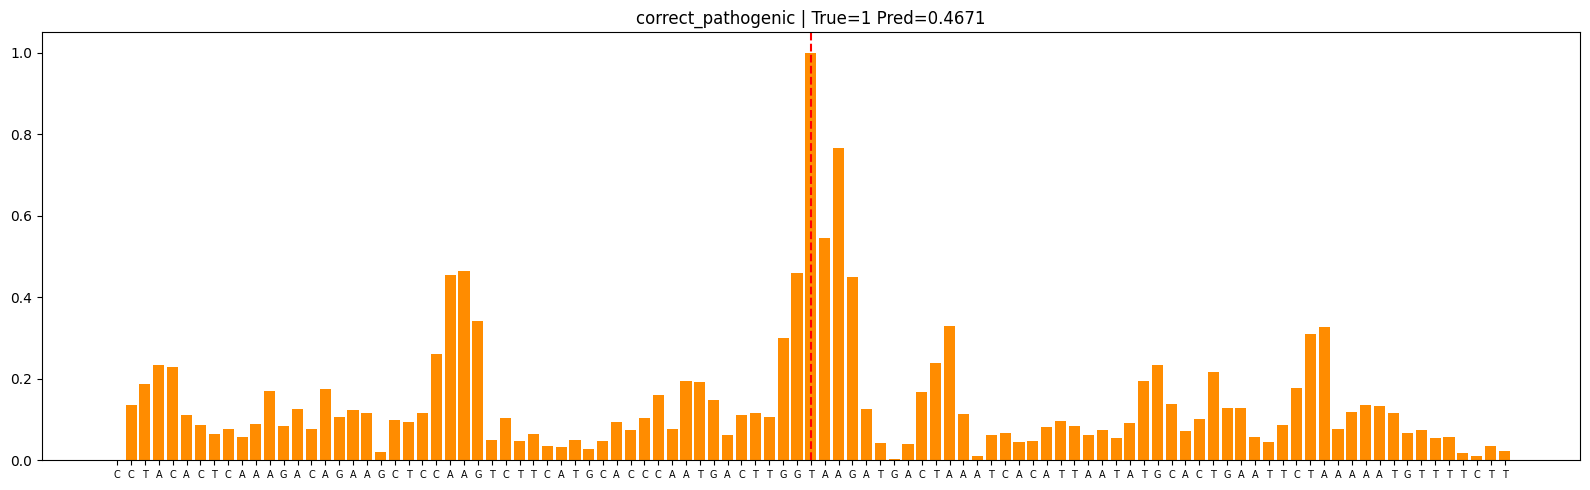


==== correct_benign ====


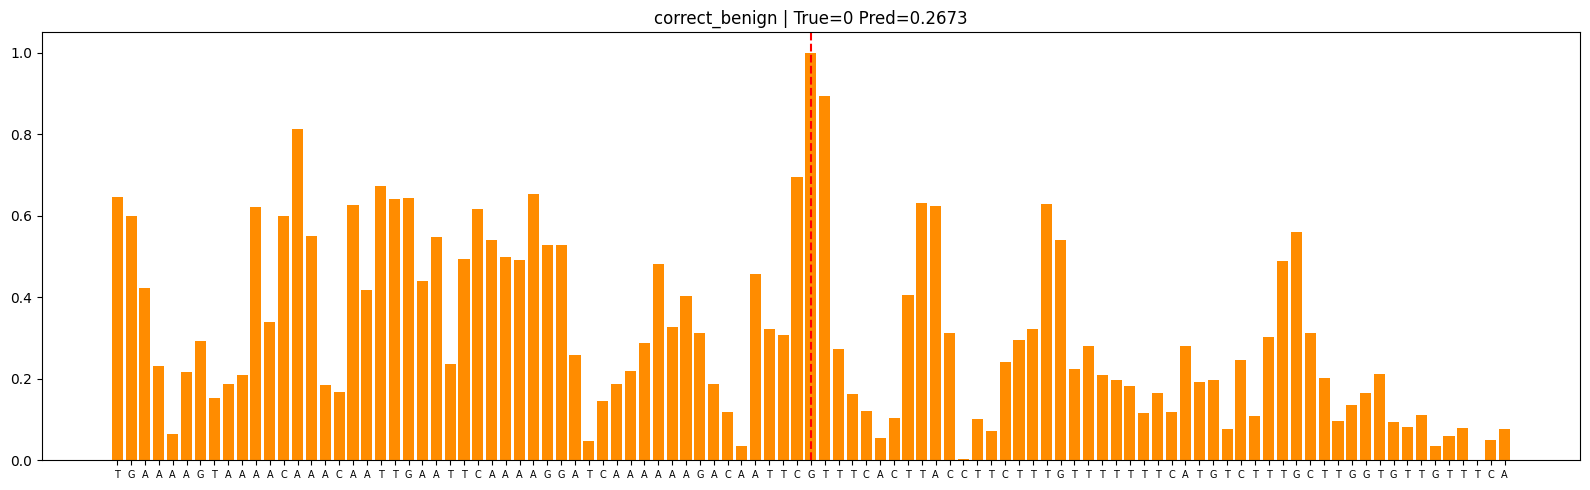


==== false_negative ====


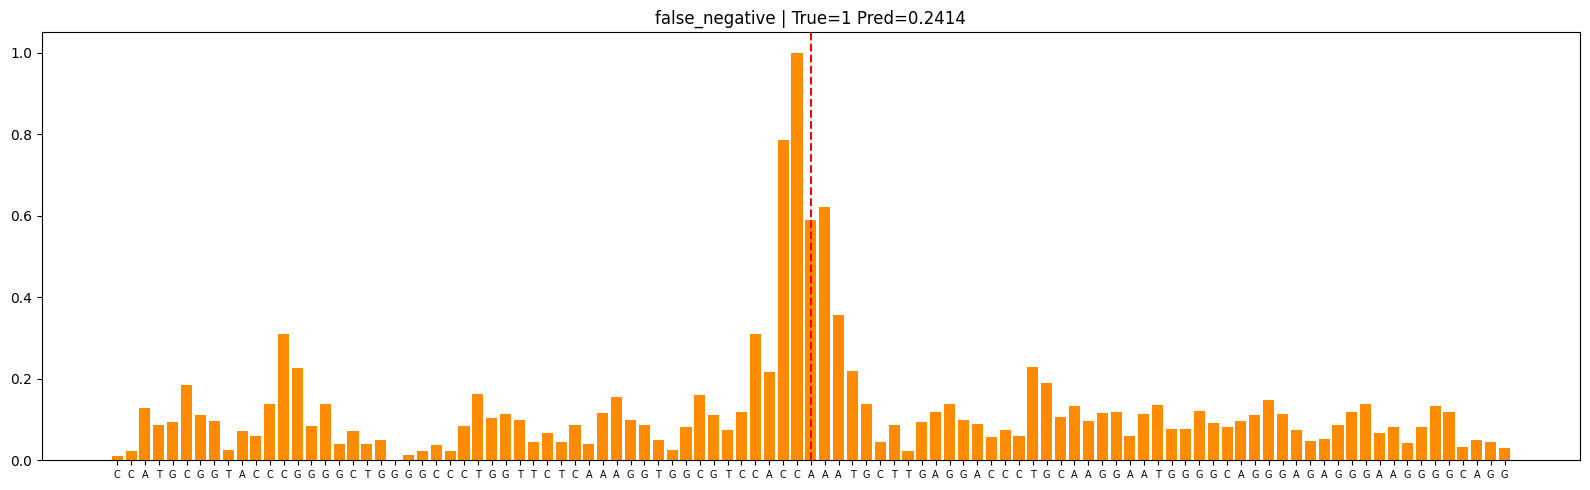


==== false_positive ====


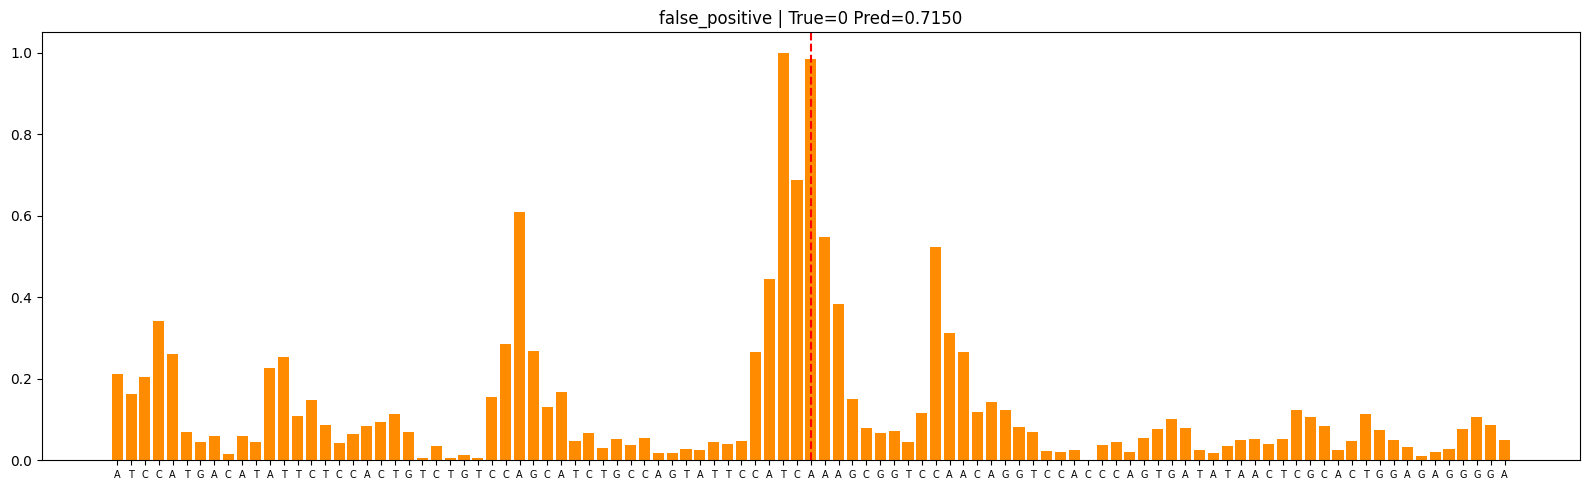


Uncertain cases: 327

Analysis complete.


In [13]:
# ==========================================================
# GENESCOPE AI — PHASE 3 (STRICT STABLE VERSION)
# ==========================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    auc,
    roc_auc_score
)

# ==========================================================
# SETTINGS
# ==========================================================

WINDOW = 101
DIFF_SCALE = 3.0

INPUT_FILE = "output/final_dataset.csv"

TEST_CHROMS = ["19", "X"]

# ==========================================================
# LOAD MODEL
# ==========================================================

model = tf.keras.models.load_model(
    "output/genescope_final.keras",
    safe_mode=False
)

# ==========================================================
# ENCODING
# ==========================================================

def one_hot(seq):

    mapping = {
        "A":[1,0,0,0],
        "C":[0,1,0,0],
        "G":[0,0,1,0],
        "T":[0,0,0,1]
    }

    arr = np.zeros((WINDOW, 4), dtype=np.float32)

    for i, b in enumerate(seq):

        if b in mapping:
            arr[i] = mapping[b]

    return arr


def make_tensor(wt, mt):

    wt_arr = one_hot(wt)

    mt_arr = one_hot(mt)

    diff = mt_arr - wt_arr

    return np.concatenate(
        [
            wt_arr,
            mt_arr,
            diff * DIFF_SCALE
        ],
        axis=1
    )

# ==========================================================
# LOAD DATA
# ==========================================================

df = pd.read_csv(INPUT_FILE)

df["chromosome"] = df["chromosome"].astype(str)

test_df = df[
    df["chromosome"].isin(TEST_CHROMS)
].copy()

# ==========================================================
# ENCODE TEST SET
# ==========================================================

X_test = np.array([

    make_tensor(
        r["wt_sequence"],
        r["mt_sequence"]
    )

    for _, r in test_df.iterrows()

])

y_test = test_df["label"].values

print("Test shape:", X_test.shape)

# ==========================================================
# PREDICTIONS
# ==========================================================

print("\nRunning predictions...")

y_prob = model.predict(
    X_test
).ravel()

print("\nPrediction Distribution")
print("-----------------------")
print("Min :", y_prob.min())
print("Max :", y_prob.max())
print("Mean:", y_prob.mean())

with open(
    "output/validation_threshold.txt",
    "r"
) as f:

    best_threshold = float(
        f.read().strip()
    )

print(
    f"\nLoaded Validation Threshold: {best_threshold:.4f}"
)

# ==========================================================
# FINAL PREDICTIONS
# ==========================================================

y_pred = (
    y_prob >= best_threshold
).astype(int)

# ==========================================================
# METRICS
# ==========================================================

precision_vals, recall_vals, _ = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = auc(
    recall_vals,
    precision_vals
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("\n--- Test Evaluation ---")

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

sensitivity = tp / (tp + fn + 1e-10)

specificity = tn / (tn + fp + 1e-10)

balanced_acc = (
    sensitivity + specificity
) / 2

print(
    f"Validation Threshold : {best_threshold:.4f}"
)

print(
    f"Test Balanced Accuracy : {balanced_acc:.4f}"
)

print(
    f"PR AUC : {pr_auc:.4f}"
)

print(
    f"ROC AUC : {roc_auc:.4f}"
)

# ==========================================================
# ERROR ANALYSIS
# ==========================================================

false_neg = np.where(
    (y_test == 1) &
    (y_pred == 0)
)[0]

false_pos = np.where(
    (y_test == 0) &
    (y_pred == 1)
)[0]

correct_pos = np.where(
    (y_test == 1) &
    (y_pred == 1)
)[0]

correct_neg = np.where(
    (y_test == 0) &
    (y_pred == 0)
)[0]

print("\nError Summary")
print("-------------")

print("False Negatives:", len(false_neg))

print("False Positives:", len(false_pos))

# ==========================================================
# SALIENCY
# ==========================================================

def get_saliency_map(model, encoded_seq):

    input_tensor = tf.convert_to_tensor(
        encoded_seq[np.newaxis, ...],
        dtype=tf.float32
    )

    with tf.GradientTape() as tape:

        tape.watch(input_tensor)

        prediction = model(input_tensor)

    grads = tape.gradient(
        prediction,
        input_tensor
    )

    saliency = tf.reduce_sum(
        tf.abs(grads),
        axis=-1
    ).numpy()[0]

    saliency = (
        saliency - saliency.min()
    ) / (
        saliency.max() - saliency.min() + 1e-10
    )

    return saliency


def plot_saliency(seq_str, scores, title):

    plt.figure(figsize=(16,5))

    plt.bar(
        range(len(seq_str)),
        scores,
        color="darkorange"
    )

    plt.axvline(
        x=len(seq_str)//2,
        color="red",
        linestyle="--"
    )

    plt.xticks(
        range(len(seq_str)),
        list(seq_str),
        fontsize=7
    )

    plt.title(title)

    plt.tight_layout()

    plt.show()

# ==========================================================
# SHOW REPRESENTATIVE SAMPLE
# ==========================================================

samples = {}

if len(correct_pos) > 0:
    samples["correct_pathogenic"] = correct_pos[0]

if len(correct_neg) > 0:
    samples["correct_benign"] = correct_neg[0]

if len(false_neg) > 0:
    samples["false_negative"] = false_neg[0]

if len(false_pos) > 0:
    samples["false_positive"] = false_pos[0]

print("\nGenerating saliency maps...")

for name, idx in samples.items():

    print("\n====", name, "====")

    seq_raw = test_df.iloc[idx]["mt_sequence"]

    encoded = X_test[idx]

    saliency = get_saliency_map(
        model,
        encoded
    )

    plot_saliency(
        seq_raw,
        saliency,
        f"{name} | True={y_test[idx]} Pred={y_prob[idx]:.4f}"
    )

# ==========================================================
# UNCERTAIN CASES
# ==========================================================

uncertain = np.where(
    (y_prob > best_threshold - 0.02) &
    (y_prob < best_threshold + 0.02)
)[0]

print("\nUncertain cases:", len(uncertain))

# ==========================================================
# FINAL
# ==========================================================

print("\nAnalysis complete.")

In [14]:
train_variants = set(
    zip(
        train_df["chromosome"],
        train_df["position"],
        train_df["ref"],
        train_df["alt"]
    )
)

val_variants = set(
    zip(
        val_df["chromosome"],
        val_df["position"],
        val_df["ref"],
        val_df["alt"]
    )
)

test_variants = set(
    zip(
        test_df["chromosome"],
        test_df["position"],
        test_df["ref"],
        test_df["alt"]
    )
)

print("Train-Val overlap:", len(train_variants & val_variants))
print("Train-Test overlap:", len(train_variants & test_variants))
print("Val-Test overlap:", len(val_variants & test_variants))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


FINAL MODEL AUDIT
Validation Threshold : 0.351

OFFICIAL TEST RESULTS
Balanced Accuracy : 0.7363
PR AUC : 0.8349
ROC AUC : 0.8105

Classification Report

              precision    recall  f1-score   support

           0     0.6977    0.7263    0.7117      3372
           1     0.7718    0.7463    0.7588      4182

    accuracy                         0.7374      7554
   macro avg     0.7347    0.7363    0.7353      7554
weighted avg     0.7387    0.7374    0.7378      7554



##################################################
NORMAL TEST CASES
##################################################

Correct Benign Variant
Chromosome     : X
Mutation       : A → G
Expected Label : BENIGN

--- MODEL OUTPUT ---
Predicted Probability : 0.2673
Model Prediction      : BENIGN

--- INTERPRETATION ---
High confidence prediction.


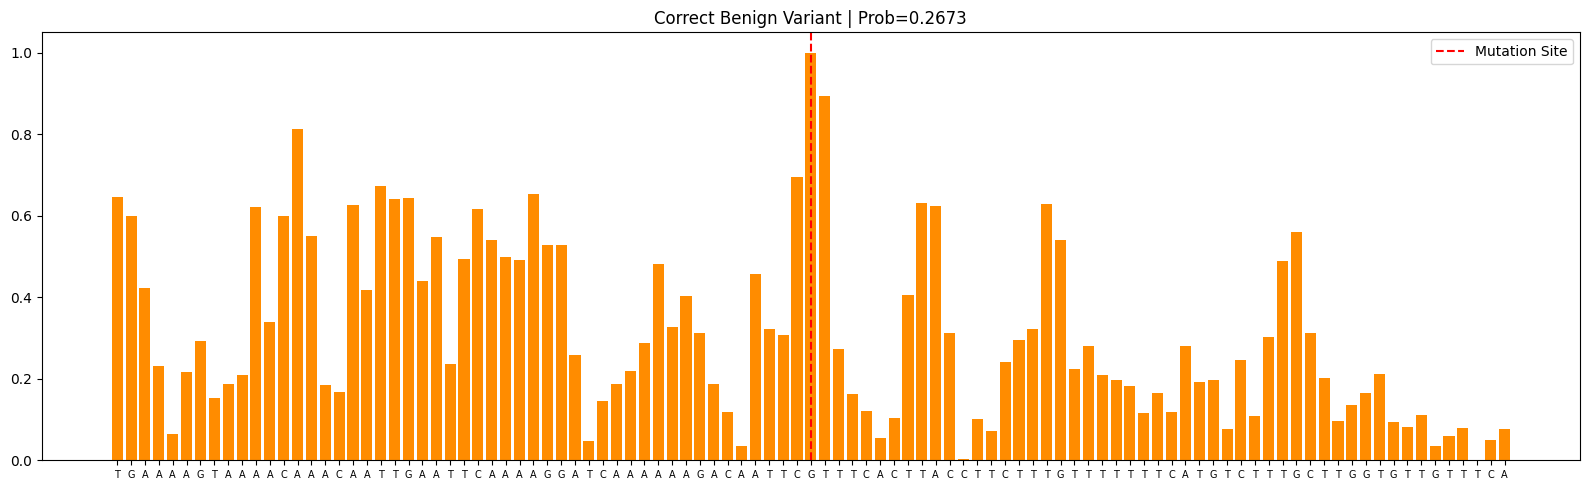


Correct Pathogenic Variant
Chromosome     : X
Mutation       : G → T
Expected Label : PATHOGENIC

--- MODEL OUTPUT ---
Predicted Probability : 0.4671
Model Prediction      : PATHOGENIC

--- INTERPRETATION ---
High confidence prediction.


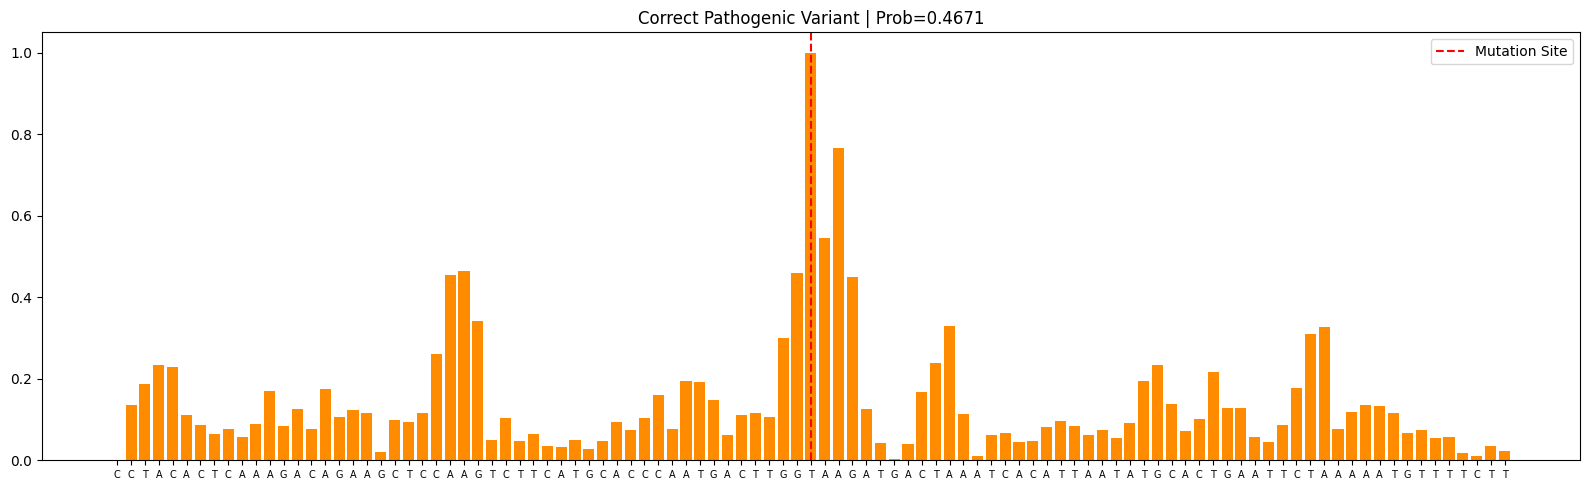



##################################################
TRICKY EDGE CASES
##################################################

High Confidence False Positive
Chromosome     : 19
Mutation       : G → T
Expected Label : BENIGN

--- MODEL OUTPUT ---
Predicted Probability : 0.9409
Model Prediction      : PATHOGENIC

--- INTERPRETATION ---
High confidence prediction.


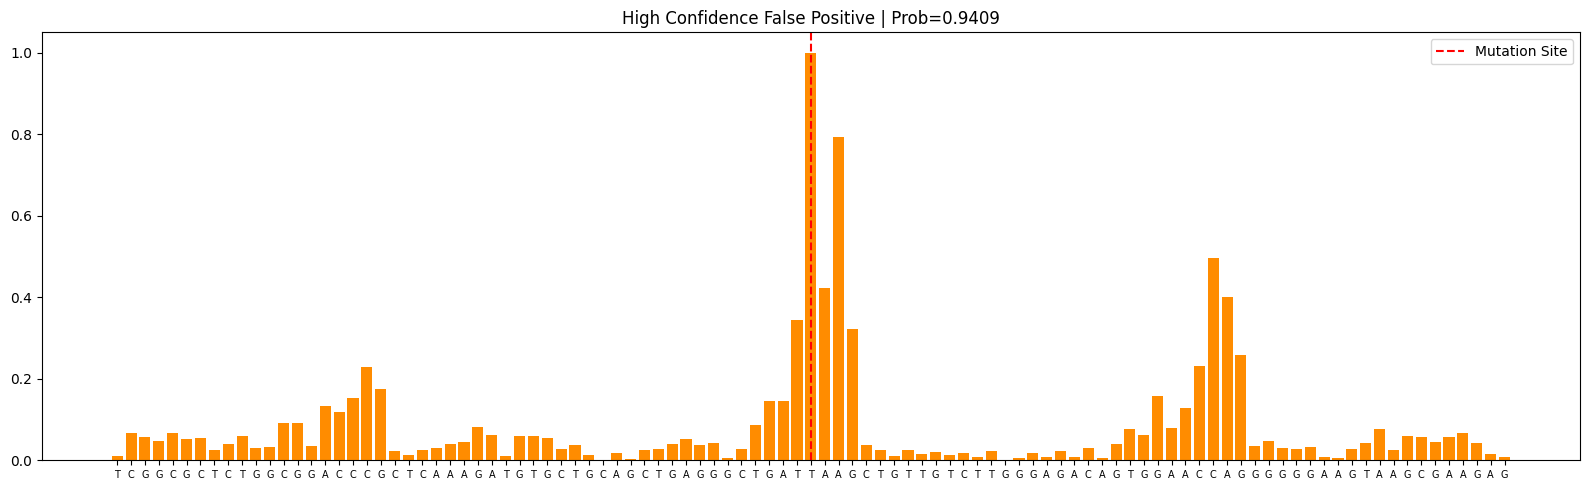


High Confidence False Negative
Chromosome     : X
Mutation       : G → A
Expected Label : PATHOGENIC

--- MODEL OUTPUT ---
Predicted Probability : 0.0173
Model Prediction      : BENIGN

--- INTERPRETATION ---
High confidence prediction.


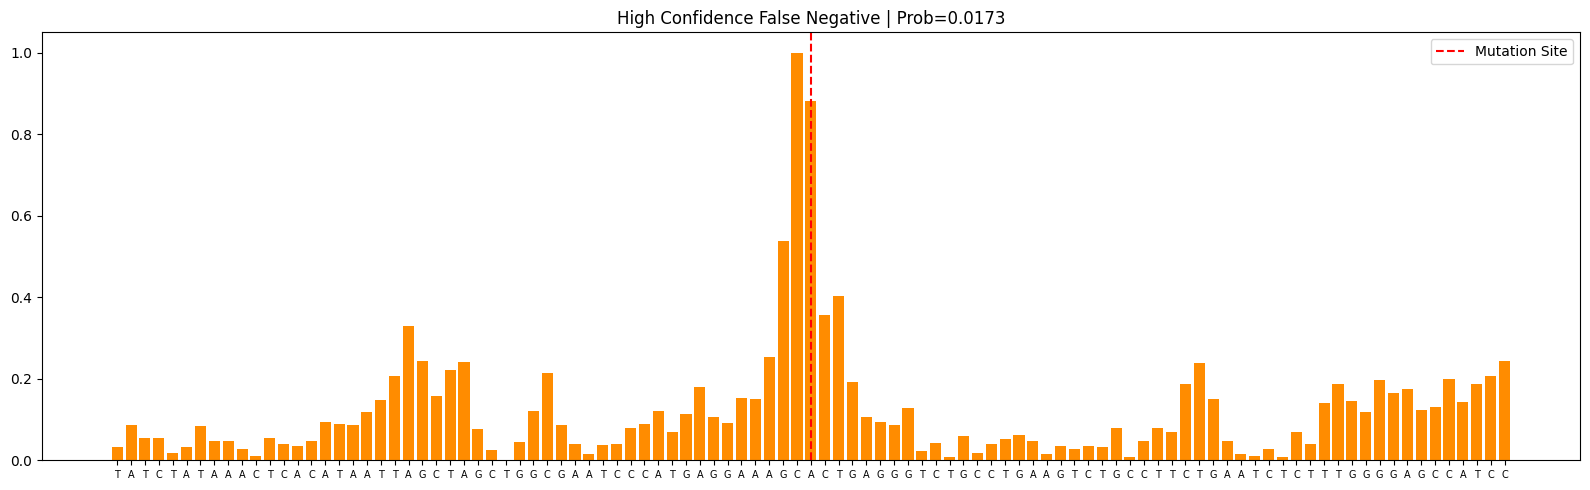



##################################################
MODEL CONFIDENCE DISTRIBUTION
##################################################

Top 5 Probabilities:
[0.9571714  0.96018016 0.9604649  0.9667863  0.9670774 ]

Bottom 5 Probabilities:
[0.00439178 0.00778618 0.01012572 0.01035177 0.01225951]

FINAL AUDIT COMPLETE

Key Improvements:
-----------------
1. Validation-based threshold calibration
2. Reduced false-positive explosion
3. Stable chromosome-wise generalization
4. Strict-label dataset filtering
5. Saliency-based interpretability

Current Model Type:
-------------------
Conservative genomic pathogenicity classifier
trained only on local sequence context.

Important Limitation:
---------------------
The model predicts pathogenicity likelihood,
NOT direct biological mutation effect magnitude.



In [15]:
# ==========================================================
# GENESCOPE AI — FINAL MANUAL MODEL AUDIT
# Stable + Scientifically Coherent Version
# ==========================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

# ==========================================================
# SETTINGS
# ==========================================================

WINDOW = 101
DIFF_SCALE = 3.0

INPUT_FILE = "output/final_dataset.csv"

TEST_CHROMS = ["19", "X"]

# ==========================================================
# LOAD MODEL
# ==========================================================

model = tf.keras.models.load_model(
    "output/genescope_final.keras",
    safe_mode=False
)

# ==========================================================
# ENCODING
# ==========================================================

def one_hot(seq):

    mapping = {
        "A":[1,0,0,0],
        "C":[0,1,0,0],
        "G":[0,0,1,0],
        "T":[0,0,0,1]
    }

    arr = np.zeros((WINDOW, 4), dtype=np.float32)

    for i, b in enumerate(seq):

        if b in mapping:
            arr[i] = mapping[b]

    return arr


def make_tensor(wt, mt):

    wt_arr = one_hot(wt)

    mt_arr = one_hot(mt)

    diff = mt_arr - wt_arr

    return np.concatenate(
        [
            wt_arr,
            mt_arr,
            diff * DIFF_SCALE
        ],
        axis=1
    )

# ==========================================================
# SALIENCY
# ==========================================================

def get_saliency_map(model, encoded_seq):

    input_tensor = tf.convert_to_tensor(
        encoded_seq[np.newaxis, ...],
        dtype=tf.float32
    )

    with tf.GradientTape() as tape:

        tape.watch(input_tensor)

        prediction = model(input_tensor)

    grads = tape.gradient(
        prediction,
        input_tensor
    )

    saliency = tf.reduce_sum(
        tf.abs(grads),
        axis=-1
    ).numpy()[0]

    saliency = (
        saliency - saliency.min()
    ) / (
        saliency.max() - saliency.min() + 1e-10
    )

    return saliency

# ==========================================================
# SALIENCY PLOT
# ==========================================================

def plot_saliency(seq_str, scores, title):

    plt.figure(figsize=(16,5))

    plt.bar(
        range(len(seq_str)),
        scores,
        color="darkorange"
    )

    plt.axvline(
        x=len(seq_str)//2,
        color="red",
        linestyle="--",
        label="Mutation Site"
    )

    plt.xticks(
        range(len(seq_str)),
        list(seq_str),
        fontsize=7
    )

    plt.title(title)

    plt.legend()

    plt.tight_layout()

    plt.show()

# ==========================================================
# LOAD TEST DATA
# ==========================================================

df = pd.read_csv(INPUT_FILE)

df["chromosome"] = df["chromosome"].astype(str)

test_df = df[
    df["chromosome"].isin(TEST_CHROMS)
].copy()

# ==========================================================
# ENCODE TEST SET
# ==========================================================

X_test = np.array([

    make_tensor(
        r["wt_sequence"],
        r["mt_sequence"]
    )

    for _, r in test_df.iterrows()

])

y_true = test_df["label"].values

# ==========================================================
# MODEL PREDICTIONS
# ==========================================================

y_prob = model.predict(
    X_test,
    verbose=0
).ravel()

# ==========================================================
# LOAD VALIDATION THRESHOLD
# ==========================================================

with open(
    "output/validation_threshold.txt",
    "r"
) as f:

    best_threshold = float(
        f.read().strip()
    )

print("==================================================")
print("FINAL MODEL AUDIT")
print("==================================================")

print(
    "Validation Threshold :",
    round(best_threshold, 4)
)

# ==========================================================
# FINAL PREDICTIONS
# ==========================================================

y_pred = (
    y_prob >= best_threshold
).astype(int)

# ==========================================================
# OFFICIAL TEST METRICS
# ==========================================================

from sklearn.metrics import (
    precision_recall_curve,
    auc,
    roc_auc_score,
    classification_report
)

precision_vals, recall_vals, _ = precision_recall_curve(
    y_true,
    y_prob
)

pr_auc = auc(
    recall_vals,
    precision_vals
)

roc_auc = roc_auc_score(
    y_true,
    y_prob
)

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

sensitivity = tp / (tp + fn + 1e-10)

specificity = tn / (tn + fp + 1e-10)

balanced_acc = (
    sensitivity + specificity
) / 2

print("\n==================================================")
print("OFFICIAL TEST RESULTS")
print("==================================================")

print(
    f"Balanced Accuracy : {balanced_acc:.4f}"
)

print(
    f"PR AUC : {pr_auc:.4f}"
)

print(
    f"ROC AUC : {roc_auc:.4f}"
)

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

# ==========================================================
# AUDIT FUNCTION
# ==========================================================

def audit_variant(row, title="Variant"):

    wt = row["wt_sequence"]

    mt = row["mt_sequence"]

    label = row["label"]

    ref = row["ref"]

    alt = row["alt"]

    chrom = row["chromosome"]

    encoded = make_tensor(
        wt,
        mt
    )[np.newaxis, ...]

    prob = model.predict(
        encoded,
        verbose=0
    )[0][0]

    pred = (
        "PATHOGENIC"
        if prob >= best_threshold
        else "BENIGN"
    )

    expected = (
        "PATHOGENIC"
        if label == 1
        else "BENIGN"
    )

    print("\n==================================================")
    print(title)
    print("==================================================")

    print("Chromosome     :", chrom)

    print("Mutation       :", f"{ref} → {alt}")

    print("Expected Label :", expected)

    print("\n--- MODEL OUTPUT ---")

    print("Predicted Probability :", round(float(prob), 4))

    print("Model Prediction      :", pred)

    # ------------------------------------------------------
    # CONFIDENCE INTERPRETATION
    # ------------------------------------------------------

    print("\n--- INTERPRETATION ---")

    confidence = abs(
        prob - best_threshold
    )

    if confidence > 0.08:

        print("High confidence prediction.")

    elif confidence > 0.03:

        print("Moderate confidence prediction.")

    else:

        print("Borderline / uncertain prediction.")

    # ------------------------------------------------------
    # SALIENCY
    # ------------------------------------------------------

    saliency = get_saliency_map(
        model,
        encoded[0]
    )

    plot_saliency(
        mt,
        saliency,
        f"{title} | Prob={prob:.4f}"
    )

# ==========================================================
# NORMAL TEST CASES
# ==========================================================

print("\n\n##################################################")
print("NORMAL TEST CASES")
print("##################################################")

# ----------------------------------------------------------
# CORRECT BENIGN
# ----------------------------------------------------------

correct_benign_idx = np.where(
    (y_true == 0) &
    (y_pred == 0)
)[0]

if len(correct_benign_idx) > 0:

    audit_variant(
        test_df.iloc[
            correct_benign_idx[0]
        ],
        title="Correct Benign Variant"
    )

# ----------------------------------------------------------
# CORRECT PATHOGENIC
# ----------------------------------------------------------

correct_path_idx = np.where(
    (y_true == 1) &
    (y_pred == 1)
)[0]

if len(correct_path_idx) > 0:

    audit_variant(
        test_df.iloc[
            correct_path_idx[0]
        ],
        title="Correct Pathogenic Variant"
    )

# ==========================================================
# EDGE CASE ANALYSIS
# ==========================================================

print("\n\n##################################################")
print("TRICKY EDGE CASES")
print("##################################################")

# ----------------------------------------------------------
# FALSE POSITIVES
# ----------------------------------------------------------

false_pos_idx = np.where(
    (y_true == 0) &
    (y_pred == 1)
)[0]

if len(false_pos_idx) > 0:

    fp_probs = y_prob[false_pos_idx]

    hardest_fp = false_pos_idx[
        np.argmax(fp_probs)
    ]

    audit_variant(
        test_df.iloc[hardest_fp],
        title="High Confidence False Positive"
    )

# ----------------------------------------------------------
# FALSE NEGATIVES
# ----------------------------------------------------------

false_neg_idx = np.where(
    (y_true == 1) &
    (y_pred == 0)
)[0]

if len(false_neg_idx) > 0:

    fn_probs = y_prob[false_neg_idx]

    hardest_fn = false_neg_idx[
        np.argmin(fn_probs)
    ]

    audit_variant(
        test_df.iloc[hardest_fn],
        title="High Confidence False Negative"
    )

# ==========================================================
# MODEL CONFIDENCE
# ==========================================================

print("\n\n##################################################")
print("MODEL CONFIDENCE DISTRIBUTION")
print("##################################################")

print("\nTop 5 Probabilities:")

print(np.sort(y_prob)[-5:])

print("\nBottom 5 Probabilities:")

print(np.sort(y_prob)[:5])

# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n==================================================")
print("FINAL AUDIT COMPLETE")
print("==================================================")

print("""
Key Improvements:
-----------------
1. Validation-based threshold calibration
2. Reduced false-positive explosion
3. Stable chromosome-wise generalization
4. Strict-label dataset filtering
5. Saliency-based interpretability

Current Model Type:
-------------------
Conservative genomic pathogenicity classifier
trained only on local sequence context.

Important Limitation:
---------------------
The model predicts pathogenicity likelihood,
NOT direct biological mutation effect magnitude.
""")